# 05 — Final Validation, Calibration, Lift and Reporting

This notebook performs the final calculations directly from the forward predictions produced by Workflow 04. It computes period-local lift, period-wise calibration, the `contact=unknown` audit, and the final LR/HGB comparison.

## 1. Setup and forward-prediction inputs

In [1]:
from pathlib import Path
import json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import brier_score_loss
SEED=42; DEPTHS=[.05,.10,.20,.50]
SRC=Path('results/segments_robustness'); OUT=Path('results/final_validation_reporting'); FIG=Path('figures/final_validation_reporting')
OUT.mkdir(parents=True,exist_ok=True); FIG.mkdir(parents=True,exist_ok=True)
pred=pd.read_csv(SRC/'forward_predictions.csv'); ordered=pd.read_csv(SRC/'ordered_robustness_summary.csv'); shuffled=pd.read_csv(SRC/'standardized_shuffled_unweighted.csv'); segment=pd.read_csv(SRC/'segment_robustness.csv')

## 2. Period-local call-depth lift

In [2]:
def chosen(g,d):
    k=max(1,int(np.ceil(d*len(g)))); z=g.nlargest(k,'score'); return k,int(z.y_binary.sum()),k*g.y_binary.mean()
def lift_table(pred):
    rows=[]
    for name,g in pred.groupby('model'):
        total_pos=int(g.y_binary.sum())
        for d in DEPTHS:
            called=captured=0; expected=0.
            for _,h in g.groupby('period_id'):
                k,c,e=chosen(h,d); called+=k; captured+=c; expected+=e
            rows.append({'model':name,'call_depth':d,'test_rows':len(g),'test_positives':total_pos,'base_rate':g.y_binary.mean(),'called':called,'captured':captured,'expected_random_same_volume':expected,'incremental':captured-expected,'lift':captured/expected,'capture_rate':captured/total_pos})
    return pd.DataFrame(rows)
def lift_ci(name,depth,reps=5000):
    a=[]
    for pid,h in pred[pred.model==name].groupby('period_id'):
        _,c,e=chosen(h,depth); a.append((pid,c,e))
    a=pd.DataFrame(a,columns=['period_id','captured','expected']); rng=np.random.default_rng(SEED); vals=[]
    for _ in range(reps):
        s=a.iloc[rng.integers(0,len(a),len(a))]; vals.append(s.captured.sum()/s.expected.sum())
    return np.percentile(vals,[2.5,97.5])
lift=lift_table(pred); lift[['ci_lower','ci_upper']]=pd.DataFrame([lift_ci(r.model,r.call_depth) for _,r in lift.iterrows()],index=lift.index); lift.to_csv(OUT/'period_local_lift.csv',index=False); display(lift.round(4))

,model,call_depth,test_rows,test_positives,base_rate,called,captured,expected_random_same_volume,incremental,lift,capture_rate,ci_lower,ci_upper
0,HGB,0.05,30526,2457,0.0805,1528,161,123.0124,37.9876,1.3088,0.0655,1.0226,1.6144
1,HGB,0.10,30526,2457,0.0805,3055,313,245.9801,67.0199,1.2725,0.1274,1.0720,1.4501
2,HGB,0.20,30526,2457,0.0805,6108,624,491.8093,132.1907,1.2688,0.2540,1.1199,1.3598
3,HGB,0.50,30526,2457,0.0805,15264,1406,1228.5754,177.4246,1.1444,0.5722,1.0919,1.1855
4,LR,0.05,30526,2457,0.0805,1528,228,123.0124,104.9876,1.8535,0.0928,1.3373,2.2451
5,LR,0.10,30526,2457,0.0805,3055,395,245.9801,149.0199,1.6058,0.1608,1.1716,1.9583
6,LR,0.20,30526,2457,0.0805,6108,689,491.8093,197.1907,1.4009,0.2804,1.1752,1.5708
7,LR,0.50,30526,2457,0.0805,15264,1459,1228.5754,230.4246,1.1876,0.5938,1.0950,1.2723


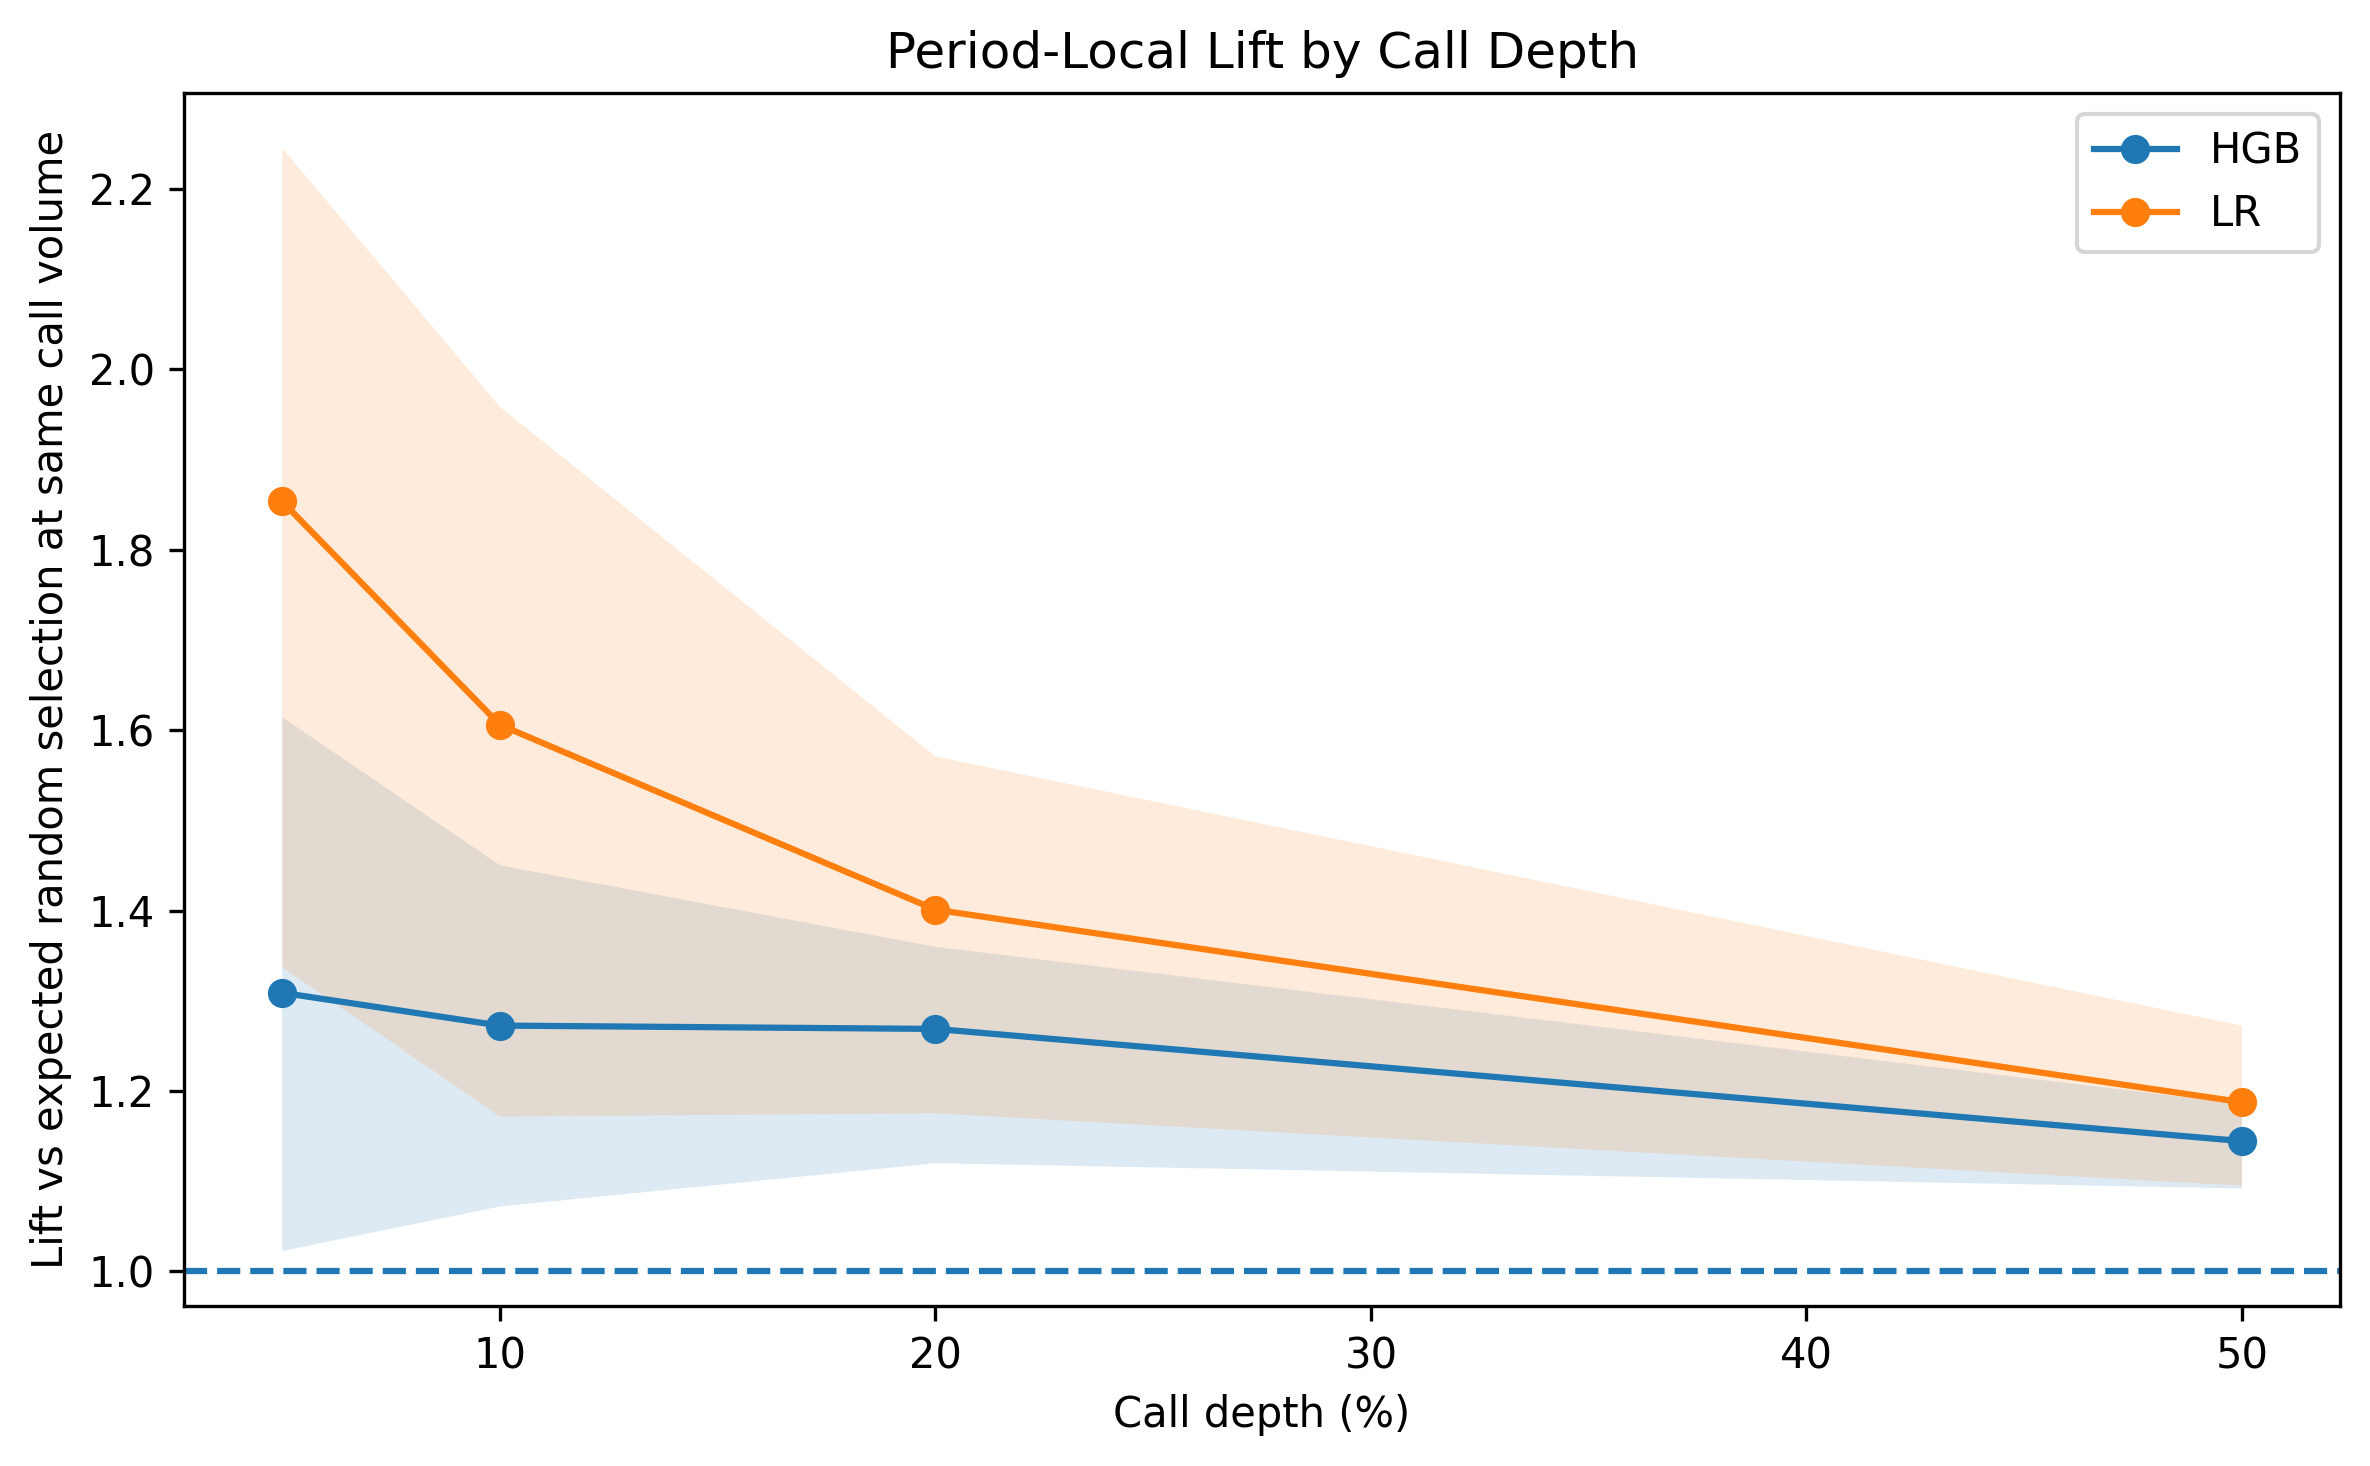

In [3]:
fig,ax=plt.subplots(figsize=(8,5))
for name,g in lift.groupby('model'): ax.plot(100*g.call_depth,g.lift,marker='o',label=name); ax.fill_between(100*g.call_depth,g.ci_lower,g.ci_upper,alpha=.15)
ax.axhline(1,linestyle='--'); ax.set(title='Period-Local Lift by Call Depth',xlabel='Call depth (%)',ylabel='Lift vs expected random selection at same call volume'); ax.legend(); plt.tight_layout(); plt.savefig(FIG/'period_local_lift.png',dpi=300,bbox_inches='tight'); plt.show()

## 3. Forward calibration assessed within period before aggregation

In [4]:
def period_calibration(pred,bins=10):
    pr=[]; br=[]
    for name,g in pred.groupby('model'):
        for pid,h in g.groupby('period_id'):
            q=min(bins,max(2,h.score.nunique())); labels=pd.qcut(h.score,q=q,labels=False,duplicates='drop'); z=h.assign(bin_id=labels).groupby('bin_id',observed=True).agg(n=('y_binary','size'),positives=('y_binary','sum'),mean_score=('score','mean'),observed_rate=('y_binary','mean')).reset_index(); z['model']=name; z['period_id']=pid; z['abs_gap']=(z.mean_score-z.observed_rate).abs(); pr.append(z); br.append({'model':name,'period_id':pid,'n':len(h),'base_rate':h.y_binary.mean(),'mean_score':h.score.mean(),'brier':brier_score_loss(h.y_binary,h.score),'ece':np.average(z.abs_gap,weights=z.n)})
    return pd.concat(pr,ignore_index=True),pd.DataFrame(br)
def aggregate_reliability(local):
    rows=[]
    for name,g in local.groupby('model'):
        for b,h in g.groupby('bin_id'):
            n=h.n.sum(); rows.append({'model':name,'bin_id':b,'n':int(n),'mean_score':np.average(h.mean_score,weights=h.n),'observed_rate':h.positives.sum()/n})
    return pd.DataFrame(rows)
local_cal,period_cal=period_calibration(pred); rel=aggregate_reliability(local_cal); local_cal.to_csv(OUT/'forward_reliability_period_bins.csv',index=False); period_cal.to_csv(OUT/'forward_calibration_by_period.csv',index=False); rel.to_csv(OUT/'forward_reliability_bins.csv',index=False)
cal=[]
for name,g in period_cal.groupby('model'):
    w=g.n.to_numpy(); cal.append({'model':name,'periods':g.period_id.nunique(),'n':int(g.n.sum()),'base_rate':np.average(g.base_rate,weights=w),'mean_score':np.average(g.mean_score,weights=w),'brier_period_weighted':np.average(g.brier,weights=w),'ece_period_weighted':np.average(g.ece,weights=w)})
cal=pd.DataFrame(cal); cal.to_csv(OUT/'forward_calibration_summary.csv',index=False); display(cal.round(4)); display(period_cal.round(4))

,model,periods,n,base_rate,mean_score,brier_period_weighted,ece_period_weighted
0,HGB,8,30526,0.0805,0.0493,0.0741,0.0337
1,LR,8,30526,0.0805,0.0754,0.0748,0.0444


,model,period_id,n,base_rate,mean_score,brier,ece
0,HGB,2,4486,0.0448,0.0312,0.0429,0.0136
1,HGB,3,6380,0.0602,0.0354,0.0571,0.0248
2,HGB,4,5215,0.0552,0.0529,0.0521,0.0074
3,HGB,6,3598,0.0611,0.0592,0.0576,0.0158
4,HGB,9,2296,0.1111,0.0632,0.1011,0.0478
5,HGB,10,258,0.4845,0.0794,0.4175,0.4051
6,HGB,11,2718,0.1659,0.0705,0.1462,0.0955
7,HGB,12,5575,0.0956,0.0525,0.0879,0.0431
8,LR,2,4486,0.0448,0.0437,0.0429,0.0112
9,LR,3,6380,0.0602,0.0976,0.0585,0.0378


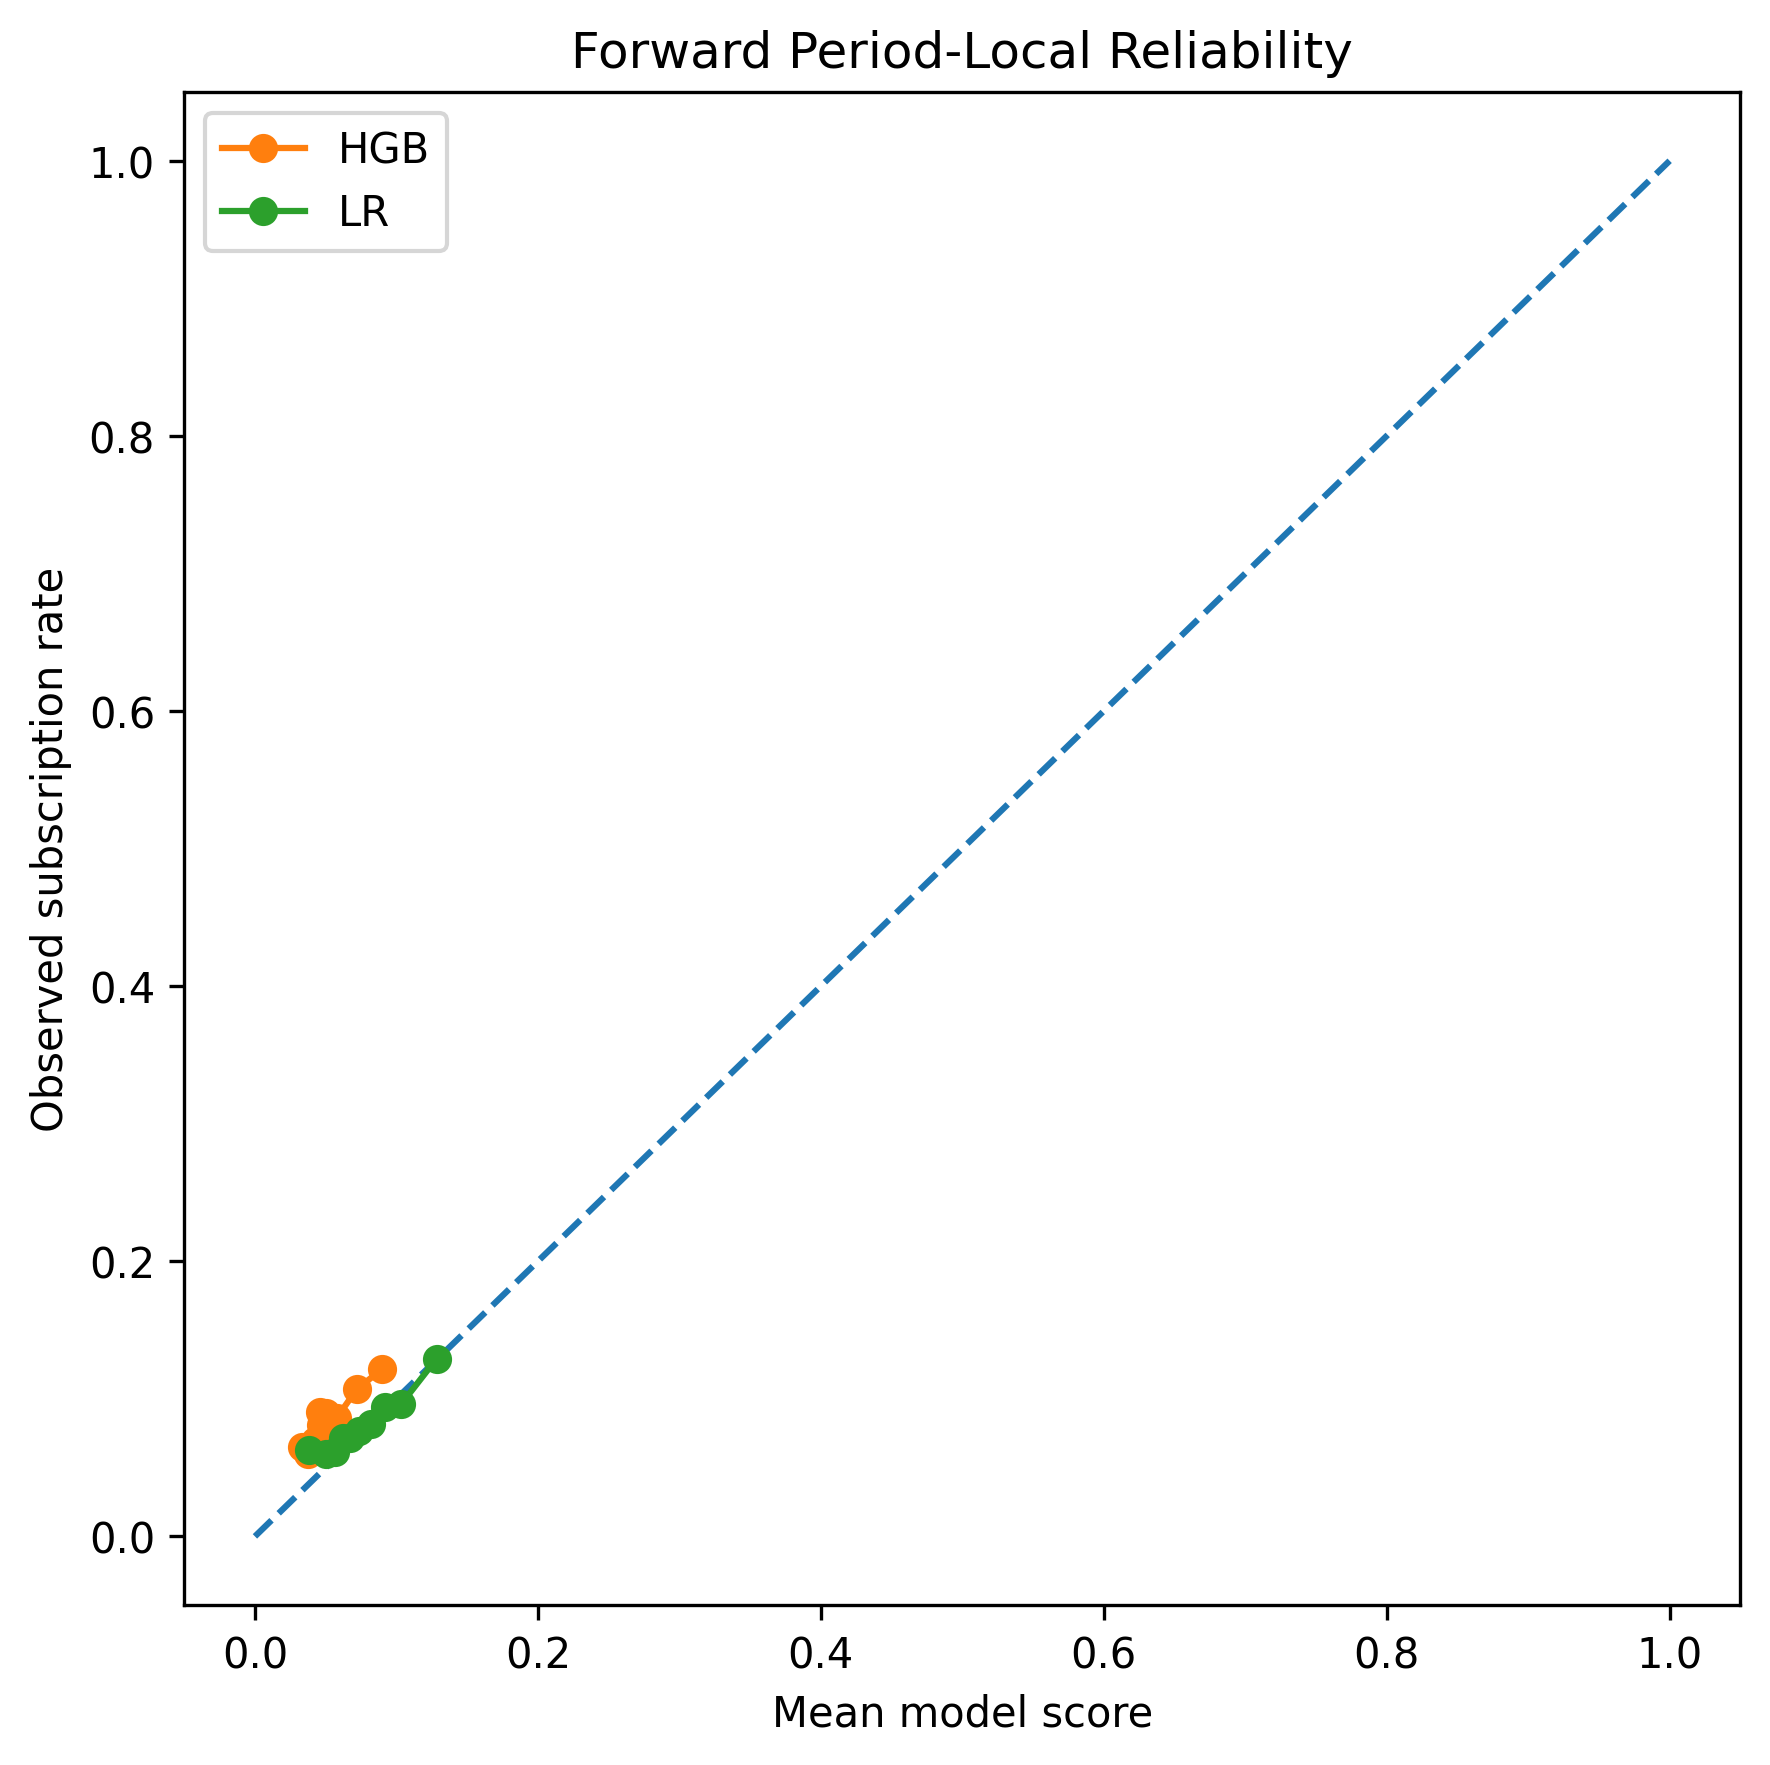

In [5]:
fig,ax=plt.subplots(figsize=(6,6)); ax.plot([0,1],[0,1],linestyle='--')
for name,g in rel.groupby('model'): ax.plot(g.mean_score,g.observed_rate,marker='o',label=name)
ax.set(title='Forward Period-Local Reliability',xlabel='Mean model score',ylabel='Observed subscription rate'); ax.legend(); plt.tight_layout(); plt.savefig(FIG/'forward_reliability.png',dpi=300,bbox_inches='tight'); plt.show()

## 4. `contact=unknown` audit at the LR period-local top-20% policy

In [6]:
lr=pred[pred.model=='LR'].copy(); lr['selected20']=False
for _,g in lr.groupby('period_id'):
    k=max(1,int(np.ceil(.20*len(g)))); lr.loc[g.nlargest(k,'score').index,'selected20']=True
unk=lr.contact.astype(str).str.lower().eq('unknown'); pos=lr.y_binary.eq(1); unknown_pos=int((unk&pos).sum()); caught=int((unk&pos&lr.selected20).sum()); missed=unknown_pos-caught
contact=pd.DataFrame([{'policy':'LR period-local top 20%','test_rows':len(lr),'base_rate':lr.y_binary.mean(),'unknown_records':int(unk.sum()),'unknown_subscribers':unknown_pos,'caught_unknown_subscribers':caught,'missed_unknown_subscribers':missed,'missed_unknown_subscriber_rate':missed/unknown_pos}]); contact.to_csv(OUT/'contact_unknown_audit.csv',index=False); display(contact.round(4))

,policy,test_rows,base_rate,unknown_records,unknown_subscribers,caught_unknown_subscribers,missed_unknown_subscribers,missed_unknown_subscriber_rate
0,LR period-local top 20%,30526,0.0805,4779,222,53,169,0.7613


## 5. Final model comparison and recommendation

In [7]:
l20=lift[np.isclose(lift.call_depth,.20)][['model','lift','captured','expected_random_same_volume','incremental']].rename(columns={'lift':'lift_20','captured':'captured_20','expected_random_same_volume':'expected_random_20','incremental':'incremental_20'})
comparison=shuffled[['model','roc_auc','pr_auc']].rename(columns={'roc_auc':'shuffled_roc_auc','pr_auc':'shuffled_pr_auc'}).merge(ordered[['model','periods','test_rows','test_positives','roc_auc_weighted','roc_auc_weighted_sd','roc_auc_unweighted','pr_auc_weighted','pr_auc_unweighted']],on='model').merge(l20,on='model').merge(cal[['model','brier_period_weighted','ece_period_weighted']],on='model').merge(segment[['model','difference','ci_lower','ci_upper']].rename(columns={'difference':'segment_minus_remainder_roc','ci_lower':'segment_ci_lower','ci_upper':'segment_ci_upper'}),on='model')
comparison.to_csv(OUT/'final_model_comparison.csv',index=False); display(comparison.round(4))

,model,shuffled_roc_auc,shuffled_pr_auc,periods,test_rows,test_positives,roc_auc_weighted,roc_auc_weighted_sd,roc_auc_unweighted,pr_auc_weighted,pr_auc_unweighted,lift_20,captured_20,expected_random_20,incremental_20,brier_period_weighted,ece_period_weighted,segment_minus_remainder_roc,segment_ci_lower,segment_ci_upper
0,LR,0.6848,0.2154,8,30526,2457,0.5663,0.0402,0.5636,0.1126,0.1726,1.4009,689,491.8093,197.1907,0.0748,0.0444,-0.0086,-0.0430,0.0257
1,HGB,0.7153,0.2447,8,30526,2457,0.5530,0.0222,0.5439,0.0968,0.1482,1.2688,624,491.8093,132.1907,0.0741,0.0337,0.0157,-0.0174,0.0468


In [8]:
recommended=comparison.sort_values(['roc_auc_weighted','lift_20'],ascending=False).iloc[0].model
decision={'recommended_pilot_model':recommended,'features':'all 12 pre-call features','weighting':'unweighted','primary_forward_metric':'test-block-size-weighted ROC-AUC across eligible forward periods','forward_gate':'minimum 5,000 prior training rows and at least 100 positives and 100 negatives in each test block','operating_mode':'rank eligible customers within each campaign period','threshold_policy':'choose call depth from capacity/economics, not default 0.5','probability_use':'ranking scores only until prospective recalibration','challenger':'HGB' if recommended=='LR' else 'LR'}
(OUT/'final_decision.json').write_text(json.dumps(decision,indent=2)); print(json.dumps(decision,indent=2))

{
  "recommended_pilot_model": "LR",
  "features": "all 12 pre-call features",
  "weighting": "unweighted",
  "primary_forward_metric": "test-block-size-weighted ROC-AUC across eligible forward periods",
  "forward_gate": "minimum 5,000 prior training rows and at least 100 positives and 100 negatives in each test block",
  "operating_mode": "rank eligible customers within each campaign period",
  "threshold_policy": "choose call depth from capacity/economics, not default 0.5",
  "probability_use": "ranking scores only until prospective recalibration",
  "challenger": "HGB"
}
